# scIDiff Tutorial: Paul15 Hematopoietic Differentiation

This notebook demonstrates **scIDiff with RNA velocity** on the classic Paul et al. 2015 hematopoiesis dataset.

## Dataset Overview

- **~2,730 mouse bone marrow cells**
- **~3,000 genes**
- Captures **myeloid differentiation** (HSC → progenitors → mature lineages)
- Clear **branching structure** ideal for trajectory inference

## What We'll Do

1. Load and preprocess the Paul15 dataset
2. Compute RNA velocity with scVelo
3. Train scIDiff **without** velocity (baseline)
4. Train scIDiff **with** velocity as biological prior
5. Compare drift fields and Jacobians
6. Visualize trajectories and regulatory archetypes
7. Quantify irreversibility

In [1]:
#!pip install --user scikit-misc
#!pip install scvelo

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvelo as scv
import torch

# scIDiff imports
import sys
sys.path.append('..')
from scqdiff.io.anndata import tensors_from_anndata
from scqdiff.models.drift import DriftField, DriftConfig

# Settings
sc.settings.verbosity = 2
scv.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor='white')

# Random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

/Users/terooatt/miniconda3/envs/scidiff/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


PyTorch version: 2.9.0
Device: cpu


## 1. Load and Preprocess Data

In [3]:
# Load Paul15 dataset
adata = sc.datasets.paul15()
print(f"Loaded {adata.n_obs} cells × {adata.n_vars} genes")
adata

Loaded 2730 cells × 3451 genes


AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'

In [4]:
# Standard preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy()  # Save raw data

# Feature selection
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3')
print(f"Selected {adata.var.highly_variable.sum()} highly variable genes")

# Keep only HVGs for downstream analysis
adata = adata[:, adata.var.highly_variable].copy()

# Scale and PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
Selected 2000 highly variable genes
computing PCA
    with n_comps=30
    finished (0:00:00)


computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:05)
computing UMAP
    finished (0:00:03)


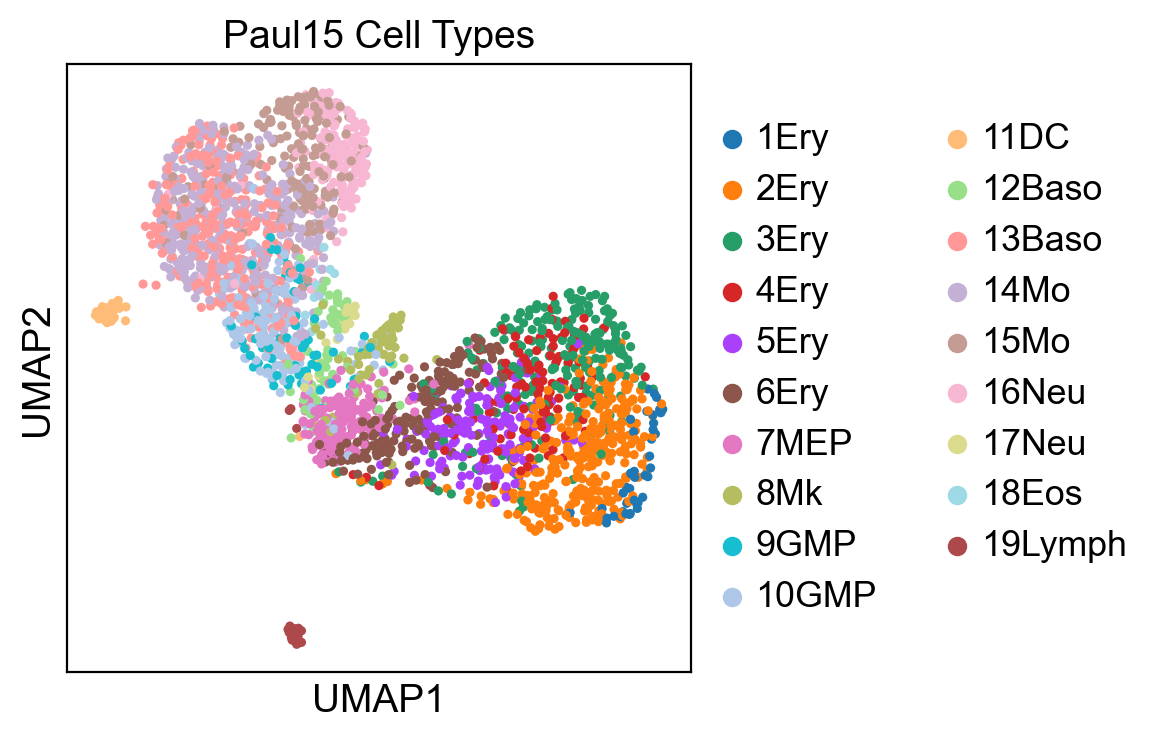

In [5]:
# Compute neighborhood graph and UMAP
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

# Visualize
sc.pl.umap(adata, color=['paul15_clusters'], title='Paul15 Cell Types')

## 2. Compute Diffusion Pseudotime (DPT)

DPT provides a trajectory ordering that we'll use as our time coordinate.

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.99658865 0.9855319  0.97633517 0.96476805 0.9514903
     0.942586   0.9365752  0.9117922  0.90555173 0.8891279  0.8810055
     0.8803887  0.87466216 0.8723676 ]
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)


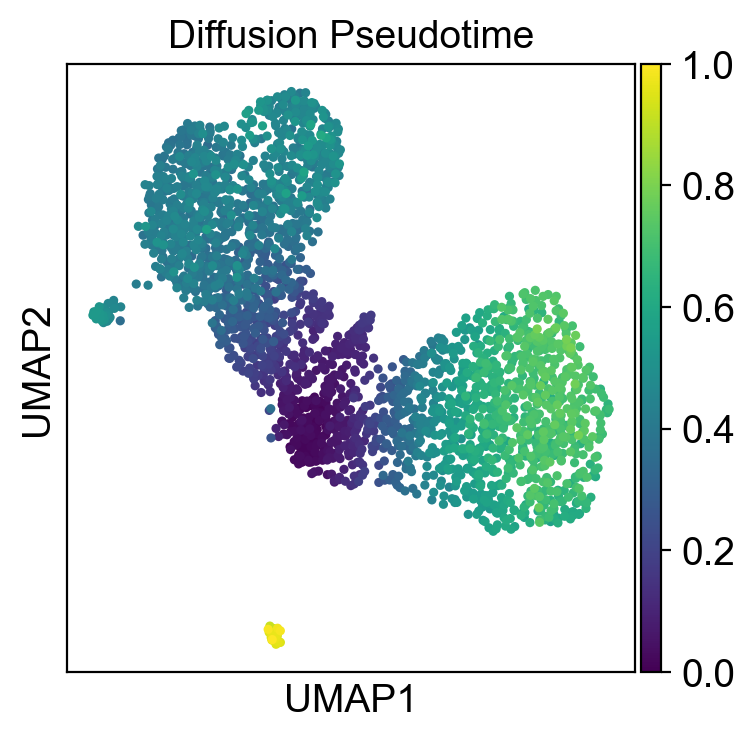

In [7]:
# Compute diffusion map
sc.tl.diffmap(adata)

# Set root cell (typically an HSC)
# We'll use the cell with highest expression of stem cell markers
x = np.asarray(adata.raw[:, "Gata2"].X).ravel()
root_idx = int(np.argmax(x))
adata.uns["iroot"] = root_idx

# Compute DPT
sc.tl.dpt(adata)

# Visualize pseudotime
sc.pl.umap(adata, color=['dpt_pseudotime'], title='Diffusion Pseudotime')

## 3) DPT pseudotime

For this tutorial, we'll use **dynamical velocity** which provides confidence estimates.

In [29]:
sc.tl.dpt(adata)  # uses adata.uns["iroot"]

# DPT pseudotime is typically stored here:
print(adata.obs["dpt_pseudotime"].describe())


computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)
count    2730.000000
mean        0.420654
std         0.210286
min         0.000000
25%         0.290981
50%         0.425451
75%         0.585013
max         1.000000
Name: dpt_pseudotime, dtype: float64


## 5) Build the scIDiff input tensor (NO velocity)
Decide what state space your drift model uses:
If your model expects PCA space:

In [43]:
#X = adata.obsm["X_pca"]
#X = adata.obsm["X_pca"][:, :10]   # <-- key change

# scanpy stores diffusion coordinates as "X_diffmap"
X = adata.obsm["X_diffmap"][:, :10]

#Now make torch tensors:
device = "cuda" if torch.cuda.is_available() else "cpu"

X = np.asarray(X).copy()   # removes negative strides + makes contiguous
X_torch = torch.tensor(X, dtype=torch.float32, device=device)

X_torch = torch.tensor(X, dtype=torch.float32, device=device)
t_torch = torch.tensor(adata.obs["dpt_pseudotime"].to_numpy(), dtype=torch.float32, device=device)


## 6) Instantiate baseline drift model (example)
This part depends on your project code, but the key point is:
drift should be a differentiable function of x and t
do not use any “velocity reference” terms
Pseudo-template:

In [44]:
# Example placeholders — replace with your actual imports/constructors
# from scqdiff.models.drift import DriftField

model_baseline = model_baseline.to(device)
model_baseline.eval()


DriftField(
  (score): MLPScore(
    (backbone): Sequential(
      (0): Linear(in_features=10, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): SiLU()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): SiLU()
    )
    (head): Linear(in_features=128, out_features=10, bias=True)
    (film): FiLMTime(
      (proj): Sequential(
        (0): Linear(in_features=1, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=256, bias=True)
      )
    )
  )
  (residual): ResidualNet(
    (net): Sequential(
      (0): Linear(in_features=11, out_features=64, bias=True)
      (1): SiLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): SiLU()
      (4): Linear(in_features=64, out_features=10, bias=True)
    )
  )
)

## 7) Jacobian computation (fixed: requires_grad)
This avoids the exact error you hit (does not require grad).

In [45]:
# sample cells for Jacobian diagnostics
n_cells_sample = 64
idx = np.random.choice(adata.n_obs, size=n_cells_sample, replace=False)

X_sample = X_torch[idx].clone().detach().requires_grad_(True)

# choose a fixed time (midpoint) OR use each cell's pseudotime
t_mid = torch.full((n_cells_sample,), 0.5, dtype=torch.float32, device=device)
# or:
# t_mid = t_torch[idx].clone().detach()

# IMPORTANT: no torch.no_grad() here
J_baseline = model_baseline.jacobian(X_sample, t_mid).detach().cpu().numpy()

print("J_baseline shape:", J_baseline.shape)


J_baseline shape: (64, 10, 10)


In [60]:
# Choose the cells you want archetypes for
idx = np.asarray(idx)                # length 256
n_cells_sample = len(idx)

# Prepare X_sample and t_mid for EXACTLY those cells
X_sample = X_torch[idx].clone().detach().requires_grad_(True)
t_mid = torch.full((n_cells_sample,), 0.5, dtype=torch.float32, device=X_sample.device)

# Compute Jacobians for all 256 cells
J_baseline = model_baseline.jacobian(X_sample, t_mid).detach().cpu().numpy()
print("J_baseline:", J_baseline.shape)  # should be (256, D, D)


J_baseline: (256, 10, 10)


In [61]:
# Example: spectral norm / Frobenius norm per cell
fro = np.linalg.norm(J_baseline.reshape(J_baseline.shape[0], -1), axis=1)
print("Jacobian Frobenius norm (min/median/max):",
      float(np.min(fro)), float(np.median(fro)), float(np.max(fro)))


Jacobian Frobenius norm (min/median/max): 0.04918656498193741 0.04933252930641174 0.04968610778450966


## build a Jacobian feature matrix
Assume J_baseline has shape (B, D, D) and corresponds to cells idx.

In [62]:
import numpy as np

J = J_baseline
B, D, _ = J.shape

S = 0.5 * (J + np.transpose(J, (0, 2, 1)))
A = 0.5 * (J - np.transpose(J, (0, 2, 1)))

# Feature vector per cell
F = np.concatenate([S.reshape(B, -1), A.reshape(B, -1)], axis=1)  # (B, 2*D*D)

# Standardize features (important for clustering)
F_mean = F.mean(axis=0, keepdims=True)
F_std  = F.std(axis=0, keepdims=True) + 1e-8
Fz = (F - F_mean) / F_std
print("Feature matrix:", Fz.shape)


Feature matrix: (256, 200)


In [63]:
from sklearn.cluster import KMeans

K = 6  # try 4–10
km = KMeans(n_clusters=K, random_state=0, n_init="auto")
labels = km.fit_predict(Fz)
centers = km.cluster_centers_  # in feature space
print("labels:", np.bincount(labels))


labels: [26 82 60 80  4  4]


## Turn each cluster into an archetype Jacobian
Two good options:
(A) Medoid archetypes (real Jacobian from a real cell; often best)

In [64]:
archetype_cell = []
archetype_J = []

for k in range(K):
    members = np.where(labels == k)[0]
    C = centers[k]
    # pick member closest to center
    m = members[np.argmin(np.linalg.norm(Fz[members] - C, axis=1))]
    archetype_cell.append(idx[m])   # original adata cell index
    archetype_J.append(J[m])        # actual Jacobian
archetype_J = np.stack(archetype_J, axis=0)  # (K, D, D)

print("Archetype Jacobians:", archetype_J.shape)
print("Archetype representative cells (adata indices):", archetype_cell)


Archetype Jacobians: (6, 10, 10)
Archetype representative cells (adata indices): [np.int64(2433), np.int64(1262), np.int64(876), np.int64(949), np.int64(1428), np.int64(2348)]


## Step 3 — compute soft archetype weights per cell (mixture)
This is what makes “archetypes” feel like archetypes: each cell is a mixture over them.
A simple, effective approach: convert distances-to-archetypes into weights with a softmax.

In [65]:
from scipy.special import softmax

# distances from each cell to each archetype center (in standardized feature space)
dists = np.linalg.norm(Fz[:, None, :] - centers[None, :, :], axis=2)  # (B, K)

# temperature controls softness (smaller -> harder assignments)
tau = 1.0
W = softmax(-dists / tau, axis=1)  # (B, K)

print("W shape:", W.shape, "row sums:", np.allclose(W.sum(axis=1), 1.0))


W shape: (256, 6) row sums: True


In [66]:
# store hard label + soft weights for sampled cells
adata.obs["J_archetype"] = np.nan
adata.obs.loc[adata.obs_names[idx], "J_archetype"] = labels

for k in range(K):
    col = f"J_arch_w{k}"
    adata.obs[col] = np.nan
    adata.obs.loc[adata.obs_names[idx], col] = W[:, k]


In [67]:
adata

AnnData object with n_obs × n_vars = 2730 × 2000
    obs: 'paul15_clusters', 'dpt_pseudotime', 'J_fro', 'J_div', 'J_asym_frac', 'J_archetype', 'J_arch_w0', 'J_arch_w1', 'J_arch_w2', 'J_arch_w3', 'J_arch_w4', 'J_arch_w5'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'iroot', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'paul15_clusters_colors', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    layers: 'velocity'
    obsp: 'distances', 'connectivities'

In [68]:
adata.obs

,paul15_clusters,dpt_pseudotime,J_fro,J_div,J_asym_frac,J_archetype,J_arch_w0,J_arch_w1,J_arch_w2,J_arch_w3,J_arch_w4,J_arch_w5
W31105,7MEP,0.020950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
W31106,15Mo,0.417415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
W31107,3Ery,0.702471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
W31108,15Mo,0.536032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
W31109,3Ery,0.715697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
W39164,2Ery,0.691800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
W39165,13Baso,0.410313,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
W39166,7MEP,0.025139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
W39167,15Mo,0.570789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


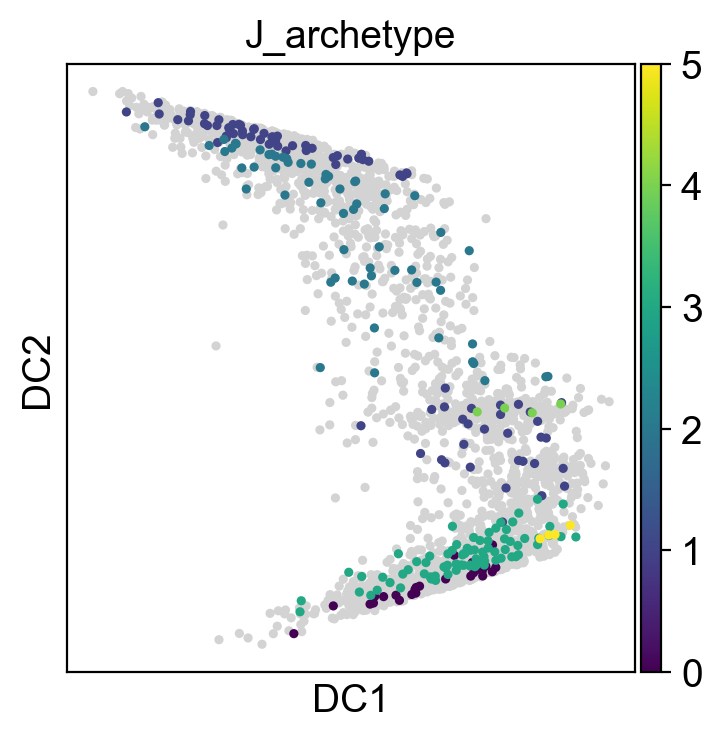

In [69]:
sc.pl.diffmap(adata, color="J_archetype", legend_loc="on data")
# or if you have UMAP:
# sc.pl.umap(adata, color="J_archetype", legend_loc="on data")


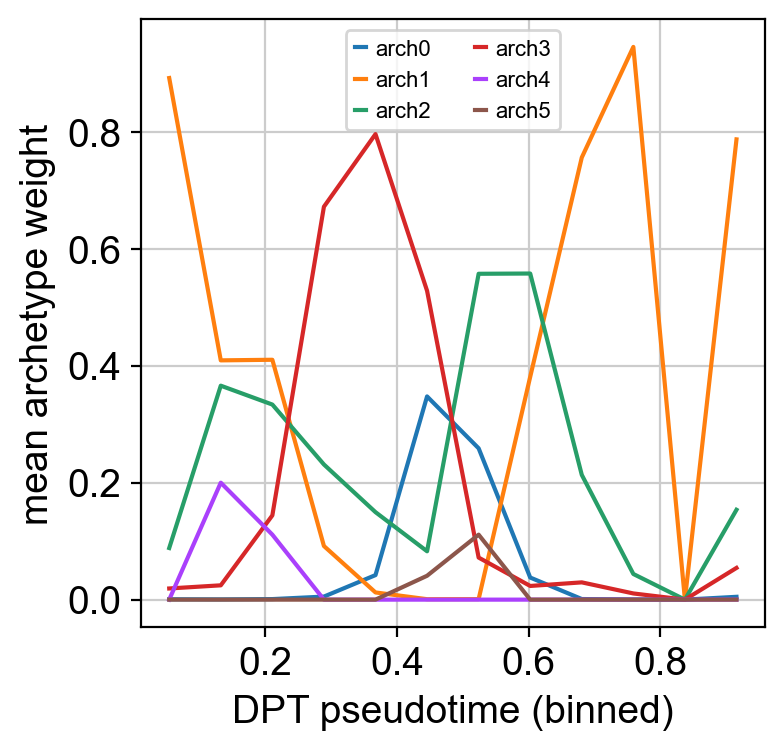

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pt = adata.obs["dpt_pseudotime"].to_numpy()

# use only cells where weights exist (sampled cells)
mask = ~adata.obs[f"J_arch_w0"].isna().to_numpy()
pt_m = pt[mask]

W_cols = [f"J_arch_w{k}" for k in range(K)]
Wm = adata.obs.loc[mask, W_cols].to_numpy()

# bin pseudotime
n_bins = 12
bins = np.linspace(pt_m.min(), pt_m.max(), n_bins + 1)
bin_id = np.digitize(pt_m, bins) - 1
bin_id = np.clip(bin_id, 0, n_bins - 1)

W_bin = np.zeros((n_bins, K))
for b in range(n_bins):
    sel = bin_id == b
    if sel.sum() > 0:
        W_bin[b] = Wm[sel].mean(axis=0)

x = 0.5 * (bins[:-1] + bins[1:])

plt.figure()
for k in range(K):
    plt.plot(x, W_bin[:, k], label=f"arch{k}")
plt.xlabel("DPT pseudotime (binned)")
plt.ylabel("mean archetype weight")
plt.legend(ncol=2, fontsize=8)
plt.show()


In [71]:
import numpy as np
import matplotlib.pyplot as plt

# choose 2D coordinates for plotting
Y = adata.obsm["X_diffmap"][:, :2]   # or adata.obsm["X_umap"][:, :2]
mask = ~adata.obs["J_archetype"].isna().to_numpy()

Y_m = Y[mask]
lab = adata.obs.loc[mask, "J_archetype"].astype(int).to_numpy()


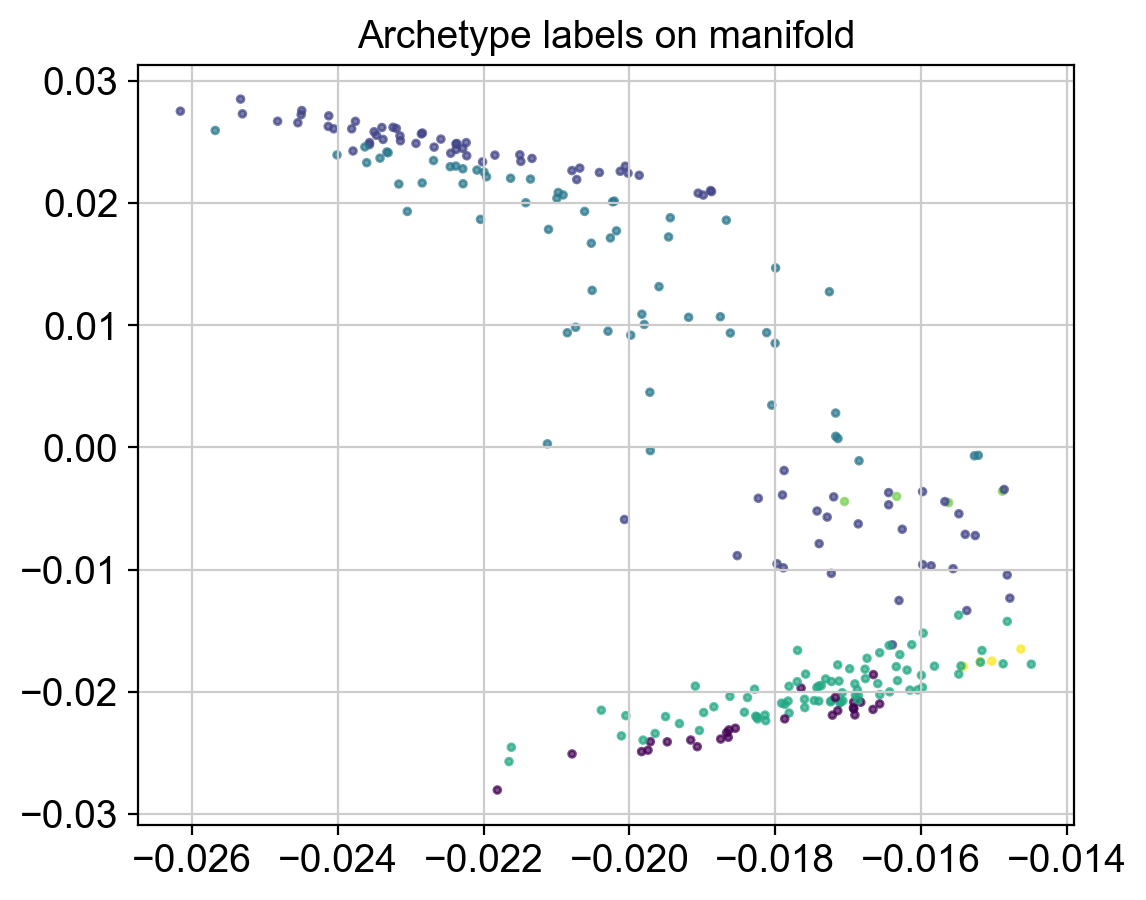

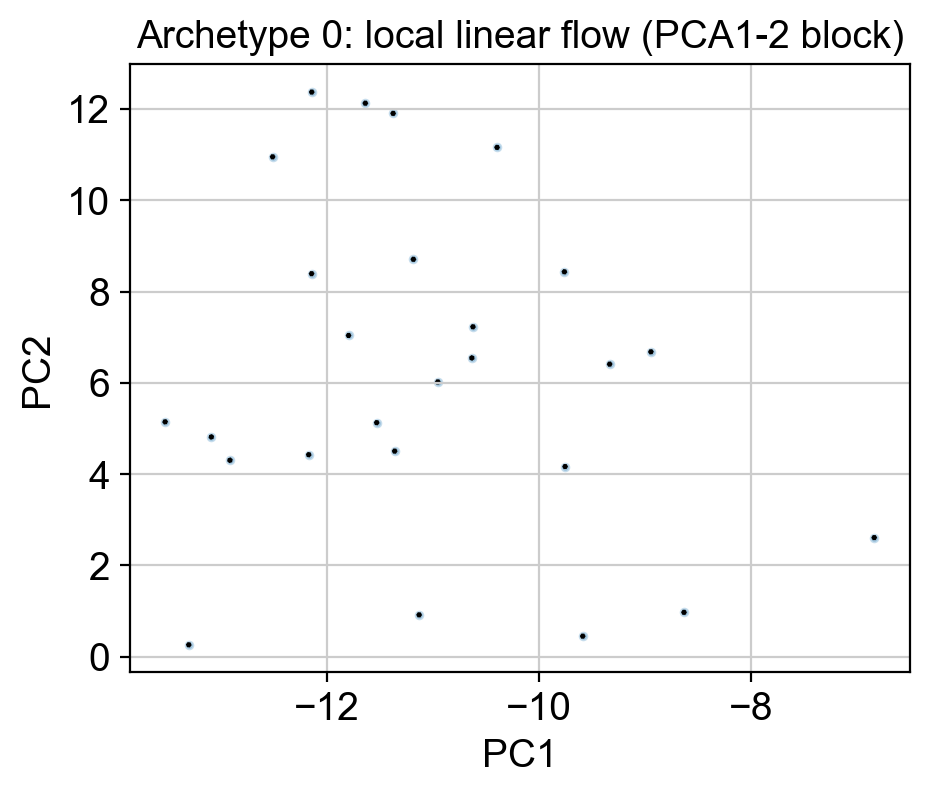

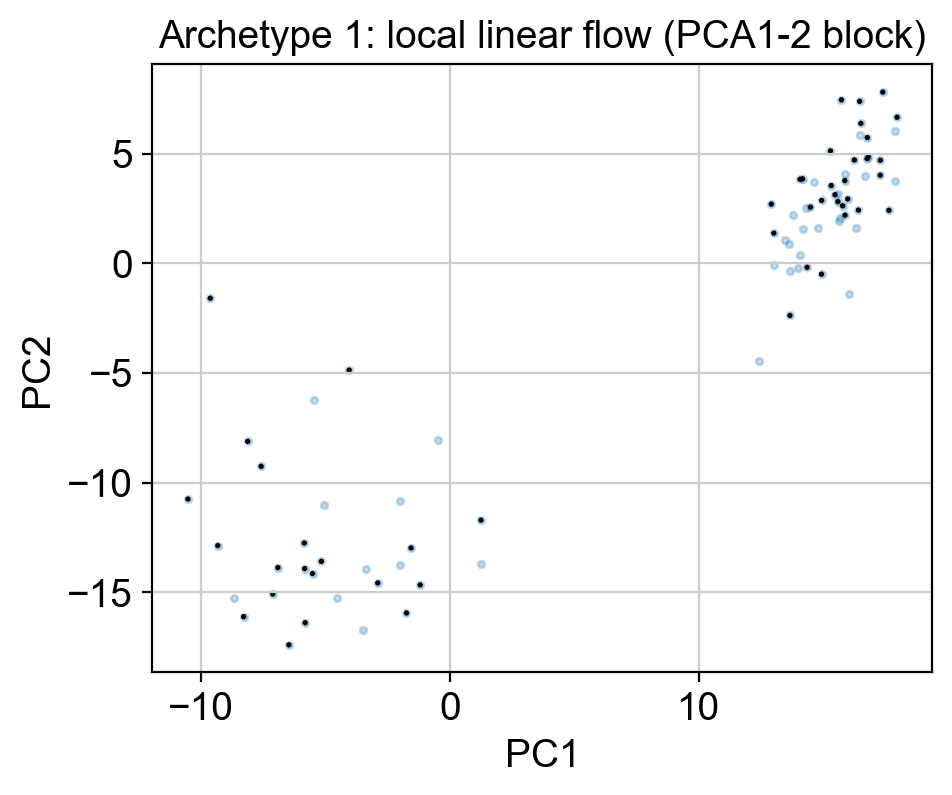

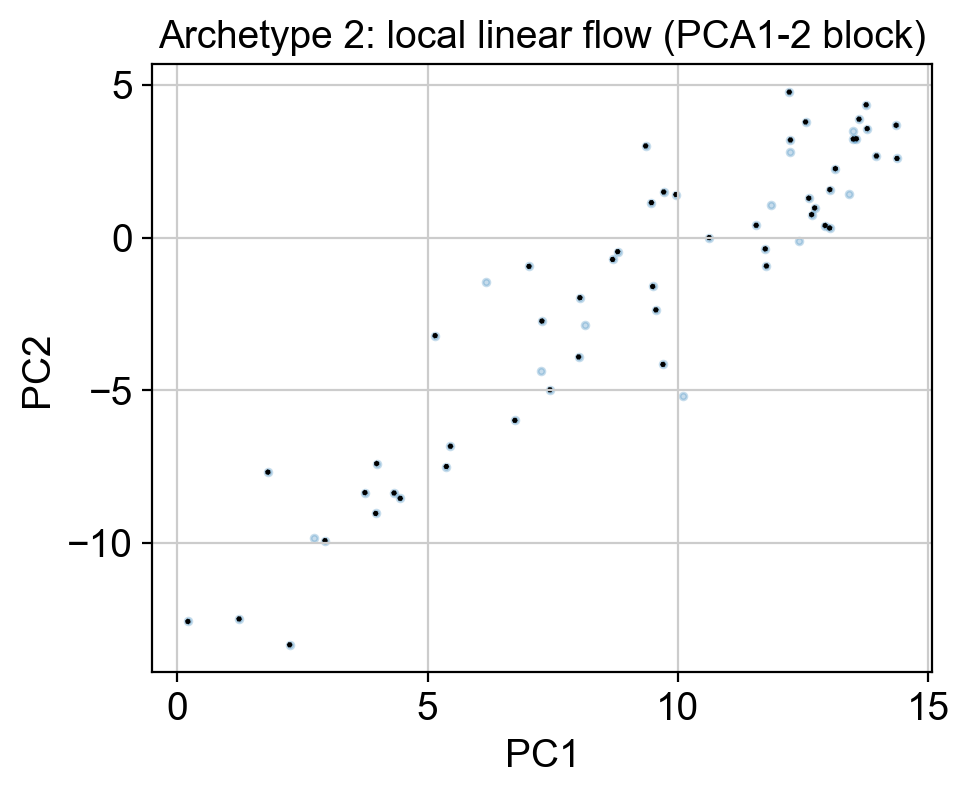

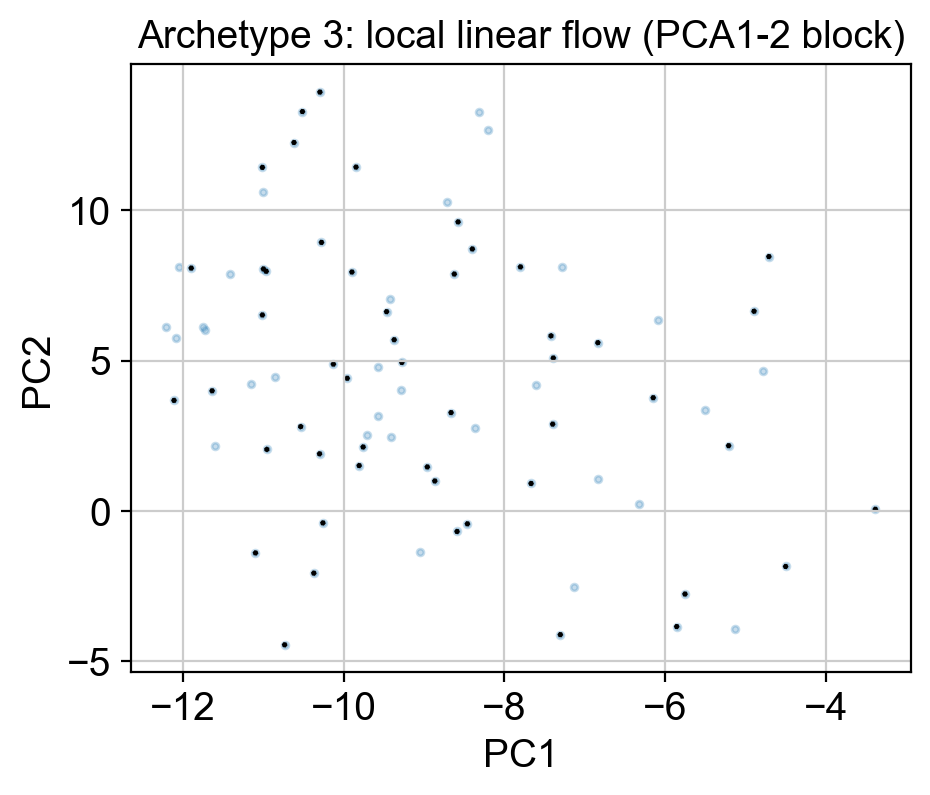

In [72]:
# If your Jacobians are in D-dimensional state space, pick 2 dims that correspond
# to your state space (e.g., PCA1-2). If your state is PCA, set state2d = X_pca[:, :2].
state2d = adata.obsm["X_pca"][:, :2]   # IMPORTANT: use the same basis as your model if possible
state2d_m = state2d[mask]

plt.figure(figsize=(6, 5))
plt.scatter(Y_m[:,0], Y_m[:,1], s=6, c=lab, alpha=0.7)
plt.title("Archetype labels on manifold")
plt.show()

# Now show per-archetype local linear flow in the 2D state space (PCA1-2)
for k in range(K):
    sel = lab == k
    if sel.sum() < 5:
        continue

    mu = state2d_m[sel].mean(axis=0)
    J2 = archetype_J[k][:2, :2]   # 2x2 block (only valid if state basis matches!)

    # sample a few points in that archetype
    pts = state2d_m[sel]
    take = pts[np.random.choice(pts.shape[0], size=min(50, pts.shape[0]), replace=False)]
    d = (take - mu) @ J2.T  # linearized drift direction

    plt.figure(figsize=(5, 4))
    plt.scatter(pts[:,0], pts[:,1], s=6, alpha=0.25)
    plt.quiver(take[:,0], take[:,1], d[:,0], d[:,1], angles="xy", scale_units="xy", scale=1.0)
    plt.title(f"Archetype {k}: local linear flow (PCA1-2 block)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.show()


In [73]:
import pandas as pd
import numpy as np

def summarize_J(Jk):
    div = np.trace(Jk)
    sym = 0.5*(Jk + Jk.T)
    asym = 0.5*(Jk - Jk.T)
    eig = np.linalg.eigvals(Jk)
    return {
        "trace(div)": float(div),
        "sym_norm": float(np.linalg.norm(sym)),
        "asym_norm": float(np.linalg.norm(asym)),
        "asym_frac": float(np.linalg.norm(asym) / (np.linalg.norm(sym)+np.linalg.norm(asym)+1e-12)),
        "max_real_eig": float(np.max(np.real(eig))),
    }

rows = []
for k in range(K):
    d = summarize_J(archetype_J[k])
    d["archetype"] = k
    rows.append(d)

df_arch = pd.DataFrame(rows).set_index("archetype")
df_arch


,trace(div),sym_norm,asym_norm,asym_frac,max_real_eig
archetype,,,,,
0,0.020711,0.034186,0.035447,0.509051,0.016831
1,0.020942,0.034213,0.035503,0.509255,0.016921
2,0.020939,0.034288,0.035516,0.508800,0.017027
3,0.020664,0.034223,0.035522,0.509314,0.016827
4,0.021416,0.034125,0.035604,0.510609,0.017231
5,0.021159,0.034119,0.035968,0.513192,0.016316


## Find the genes that most strongly contribute to the unstable dynamical mode defining the each archetypes.

“We identified the dominant unstable eigenmode of the inferred dynamics (archetype) during early reprogramming and projected this mode back to gene space. The highest-loading genes included canonical Yamanaka factors, indicating that these genes drive exit from the somatic attractor.”

In [88]:
k = 0  # archetype index you want to analyze
Jk = archetype_J[k]

# extract the dominant unstable eigenmode
eigvals, eigvecs = np.linalg.eig(Jk)

# dominant unstable mode
idx_unstable = np.argmax(np.real(eigvals))
lambda_u = np.real(eigvals[idx_unstable])
v = np.real(eigvecs[:, idx_unstable])   # shape (D,)

print("Dominant eigenvalue:", lambda_u)


Dominant eigenvalue: 0.016830698


In [89]:
D = v.shape[0]
PCs = adata.varm["PCs"][:, :D]   # (genes × D)

gene_scores = PCs @ v            # (genes,)

#Interpretation:
# gene_scores[g] = how strongly gene g contributes to this fingerprint
# sign = direction (up/down along the mode)
# magnitude = importance

In [98]:
# rank strongest gene contributors
gene_scores_abs = np.abs(gene_scores)
rank = np.argsort(-gene_scores_abs)

top_n = 10
top_genes = adata.var_names[rank[:top_n]]
top_scores = gene_scores[rank[:top_n]]

for g, s in zip(top_genes, top_scores):
    print(f"{g:15s} {s:+.4f}")


Ccl5            +0.1161
H2-Aa           -0.1125
Ctsw            +0.1100
H2-Eb1          -0.1092
Plbd1           -0.1072
Pf4             -0.1027
Cd74            -0.0962
H2-Ab1          -0.0934
Lgals3          -0.0902
Ifi30           -0.0840


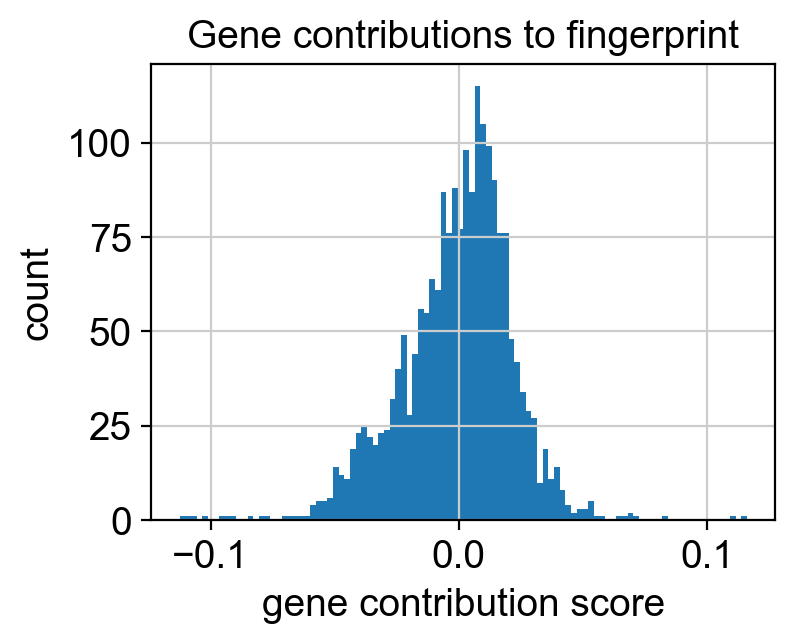

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.hist(gene_scores, bins=100)
plt.xlabel("gene contribution score")
plt.ylabel("count")
plt.title("Gene contributions to fingerprint")
plt.show()


In [96]:
gene_set = set(top_genes)


In [97]:
n_perm = 1000
null_scores = []

for _ in range(n_perm):
    v_perm = np.random.permutation(v)
    null_scores.append(np.max(np.abs(PCs @ v_perm)))

null_scores = np.array(null_scores)
obs = np.max(np.abs(gene_scores))

print("empirical p-value:", (null_scores >= obs).mean())


empirical p-value: 0.596
